# Bond Pricing — YTM, Dirty/Clean, Day-Counts

## Why this matters

Fixed income is **half of all global capital markets**. Every quant role at an IB or AM touches bonds in some way: pricing, P&L, risk, hedging. The mechanics seem boring until you realise they're 90% of the job.

You will be asked, in any FI interview:
1. Price a bond from a YTM. Why is YTM not a real interest rate?
2. Solve for YTM given a price (Newton's method on the pricing function).
3. **Dirty vs clean price** — what's the difference and why does it exist?
4. Day-count conventions: 30/360 vs Actual/Actual vs Actual/365 — which goes where?
5. Why is bond price ≠ par when YTM ≠ coupon rate?
6. Compute accrued interest. Show price discontinuity at coupon dates.

This notebook covers all six on real-world coupon bonds with realistic 2026 rates.

## The 30-second concept

A bond is a sequence of cash flows: periodic coupons $C$ paid every accrual period, plus principal $F$ (face value) at maturity. Price by discounting:

$$P = \sum_{i=1}^N \frac{C_i}{(1 + y/m)^{m \, t_i}} + \frac{F}{(1 + y/m)^{m \, T}}$$

where $y$ is the yield to maturity, $m$ is the compounding frequency (2 = semi-annual, 1 = annual), $t_i$ is time to coupon $i$.

**YTM** is the single discount rate that prices all cash flows correctly. It's a **summary statistic**, not a real rate — it's the IRR of the bond's cash flows.

### Three price quantities

| Quantity | Definition | Used by |
|---|---|---|
| **Dirty price** | PV of all remaining cash flows | Trading systems |
| **Clean price** | Dirty price − accrued interest | Quoted convention |
| **Accrued interest** | Coupon earned but not yet paid: $C \cdot (\text{days since last coupon} / \text{days in period})$ | Settlement |

Quoted prices are clean (smooth between coupon dates). Settlement always happens at dirty (full PV).

## Day-count conventions

| Convention | Used for | Day count rule |
|---|---|---|
| **30/360** | US corporate bonds | Each month = 30 days, year = 360 |
| **Actual/Actual** (ICMA) | US Treasuries | Actual days, year = days in period × 2 (semi-annual) |
| **Actual/365** | UK gilts, money market | Actual days, year = 365 |
| **Actual/360** | LIBOR / EUR / USD money market | Actual days, year = 360 |

**Same bond, different convention → different price.** This causes a non-trivial fraction of FI bugs.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from datetime import date, timedelta

print('Bond pricing — focus is on mechanics. We use direct calculations rather than QuantLib daycounters.')

Bond pricing — focus is on mechanics. We use direct calculations rather than QuantLib daycounters.


## Implementation — bond pricer

In [2]:
def bond_price(face, coupon_rate, ytm, T, freq=2):
    """Price a coupon bond.

    face         : par value (typically 100 or 1000)
    coupon_rate  : annual coupon rate (decimal, e.g. 0.05 for 5%)
    ytm          : annual yield to maturity (decimal)
    T            : time to maturity (years)
    freq         : coupon frequency per year (2 = semi-annual)

    Assumes T is an integer multiple of 1/freq for simplicity (no broken period).
    """
    n = int(round(T * freq))
    coupon = face * coupon_rate / freq
    cash_flows = np.array([coupon] * n)
    cash_flows[-1] += face                    # principal at maturity
    times = np.arange(1, n + 1) / freq        # in years
    discount = (1 + ytm / freq) ** (freq * times)
    return np.sum(cash_flows / discount)


# A 5-year, 4% coupon, semi-annual bond yielding 5%
P = bond_price(face=100, coupon_rate=0.04, ytm=0.05, T=5, freq=2)
print(f'5y 4% coupon @ 5% YTM (semi-annual): ${P:.4f}')
print('→ Below par (96.xx) because YTM > coupon rate. Bond trades at a discount.')

# Same bond yielding 3%
P_high = bond_price(100, 0.04, 0.03, 5, freq=2)
print(f'\n5y 4% coupon @ 3% YTM: ${P_high:.4f}')
print('→ Above par (104.xx) because YTM < coupon rate. Bond trades at a premium.')

5y 4% coupon @ 5% YTM (semi-annual): $95.6240
→ Below par (96.xx) because YTM > coupon rate. Bond trades at a discount.

5y 4% coupon @ 3% YTM: $104.6111
→ Above par (104.xx) because YTM < coupon rate. Bond trades at a premium.


## Solving for YTM given price

Newton's method or Brent on the pricing function. The function is monotonically decreasing in $y$ (higher yield → lower price), so a unique solution exists.

In [3]:
def yield_to_maturity(price, face, coupon_rate, T, freq=2, lo=-0.50, hi=2.0):
    """Solve for YTM given dirty price."""
    f = lambda y: bond_price(face, coupon_rate, y, T, freq) - price
    if f(lo) * f(hi) > 0:
        return np.nan
    return brentq(f, lo, hi, xtol=1e-10)


# Round-trip: price → YTM should recover the input yield
y_in = 0.05
P    = bond_price(100, 0.04, y_in, 5, freq=2)
y_out = yield_to_maturity(P, 100, 0.04, 5, freq=2)
print(f'YTM in:  {y_in:.6f}')
print(f'Price:   {P:.6f}')
print(f'YTM out: {y_out:.6f}  (round-trip error: {abs(y_in - y_out):.2e})')

# Real-world: a 10y Treasury at $98.50, 4% coupon
y_treasury = yield_to_maturity(98.50, 100, 0.04, 10, freq=2)
print(f'\n10y Treasury at \$98.50 with 4% coupon: YTM = {y_treasury*100:.4f}%')
print(f'  → discount of \$1.50 corresponds to ~16 bps yield premium')

YTM in:  0.050000
Price:   95.623968
YTM out: 0.050000  (round-trip error: 4.44e-16)

10y Treasury at \$98.50 with 4% coupon: YTM = 4.1851%
  → discount of \$1.50 corresponds to ~16 bps yield premium


## Accrued interest, dirty vs clean price

Between coupon dates, the bond accrues a portion of the next coupon. The accrued interest is added to the clean (quoted) price to settle:

$$P_{dirty} = P_{clean} + \text{Accrued}$$

$$\text{Accrued} = \frac{\text{days since last coupon}}{\text{days in coupon period}} \times \text{coupon}$$

The **clean** price is smooth across coupon dates (used for quoting and trading). The **dirty** price jumps down by the coupon amount at each coupon date (the coupon was paid, so the bondholder no longer owns it).

Accrued interest at day 90 of 182-day period: $1.2363
  → bondholder has earned half (90/182) of the next $2.50 coupon


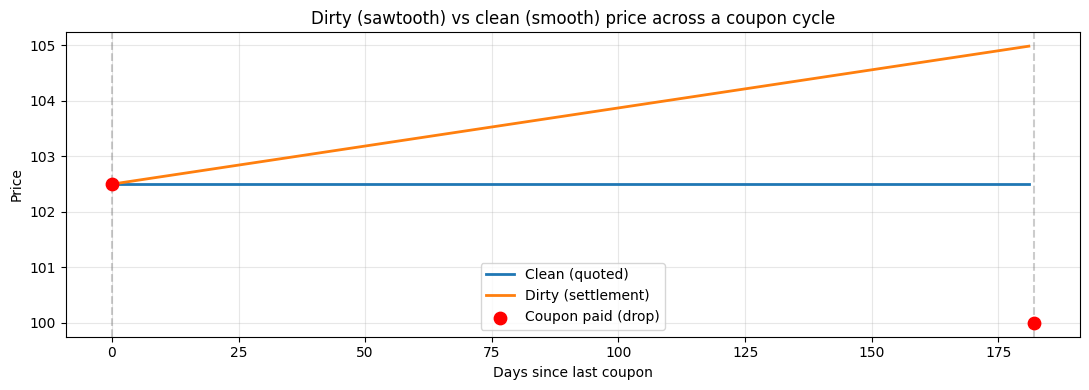


→ Quoted prices are CLEAN (smooth). Settlement uses DIRTY (full PV including accrued).


In [4]:
def accrued_interest(face, coupon_rate, days_since_last, days_in_period):
    """Standard accrued interest calculation."""
    coupon = face * coupon_rate / 2   # semi-annual
    return coupon * days_since_last / days_in_period


# Bond with 5% coupon, 90 days since last coupon, 182 days in period
ai = accrued_interest(100, 0.05, 90, 182)
print(f'Accrued interest at day 90 of 182-day period: ${ai:.4f}')
print(f'  → bondholder has earned half (90/182) of the next $2.50 coupon')

# Plot dirty vs clean price across one coupon cycle
days_grid = np.arange(0, 182)
P_clean   = 102.5   # arbitrary
ai_grid   = [accrued_interest(100, 0.05, d, 182) for d in days_grid]
P_dirty_grid = P_clean + np.array(ai_grid)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(days_grid, [P_clean]*len(days_grid), label='Clean (quoted)', lw=2)
ax.plot(days_grid, P_dirty_grid, label='Dirty (settlement)', lw=2)
ax.scatter([182], [P_clean - 2.5], s=80, color='red', zorder=5, label='Coupon paid (drop)')
ax.scatter([0],   [P_clean],       s=80, color='red', zorder=5)
ax.axvline(0, color='gray', ls='--', alpha=0.4); ax.axvline(182, color='gray', ls='--', alpha=0.4)
ax.set_xlabel('Days since last coupon'); ax.set_ylabel('Price')
ax.set_title('Dirty (sawtooth) vs clean (smooth) price across a coupon cycle')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('\n→ Quoted prices are CLEAN (smooth). Settlement uses DIRTY (full PV including accrued).')

## Real-world: pricing a 10y US Treasury at 4% coupon

Use today's curve to price a hypothetical 10y Treasury. With 4.3% SOFR-flat curve, a 4% coupon bond should price below par.

In [5]:
# Parameters: 10y Treasury, 4% coupon, semi-annual, 4.3% YTM
face = 100
coupon = 0.04
ytm = 0.043
T = 10
freq = 2

P = bond_price(face, coupon, ytm, T, freq)
print(f'10y 4% Treasury at 4.30% YTM: ${P:.4f}')

# What if rates move ±50 bps?
for delta in [-0.005, 0.0, +0.005]:
    P_d = bond_price(face, coupon, ytm + delta, T, freq)
    print(f'  YTM = {(ytm+delta)*100:.2f}%: price = ${P_d:.4f}, change = ${P_d - P:+.4f}')

print('\n→ ~$4 price change for each 50 bp move in 10y yield. That\'s ~$8 per bp / $100 face.')

10y 4% Treasury at 4.30% YTM: $97.5824
  YTM = 3.80%: price = $101.6510, change = $+4.0686
  YTM = 4.30%: price = $97.5824, change = $+0.0000
  YTM = 4.80%: price = $93.7050, change = $-3.8774

→ ~$4 price change for each 50 bp move in 10y yield. That's ~$8 per bp / $100 face.


## Exercises

### Exercise 1 — Zero-coupon bond pricing

Price a 5-year zero-coupon bond with $100 face value at yields 3%, 5%, 8%. Confirm the formula $P = F / (1+y/m)^{mT}$ where $m=2$ for semi-annual.

In [6]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
face, T, freq = 100, 5, 2
for y in [0.03, 0.05, 0.08]:
    P_formula = face / (1 + y/freq)**(freq*T)
    P_func    = bond_price(face, 0.0, y, T, freq)
    print(f'y={y:.0%}: formula ${P_formula:.4f}, func ${P_func:.4f}, agree: {abs(P_formula-P_func)<1e-10}')
```

_Zero-coupon = single cash flow at T. Price = F/(1+y/2)^(2T)._

</details>

### Exercise 2 — YTM on a deep-discount bond

A 30y bond with 2% coupon trades at \$60. Compute YTM. Why is it well above the coupon rate?

In [7]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
y = yield_to_maturity(60, 100, 0.02, 30, freq=2)
print(f'YTM: {y*100:.4f}%')
print('→ Coupon < YTM → bond at deep discount (paying $60 vs $100 face for the principal alone).')
```

_YTM ~5.5%. Big discount because coupon doesn't compensate for the term._

</details>

### Exercise 3 — Coupon vs YTM table

For a 10y bond, table prices for coupons in {0%, 2%, 4%, 6%, 8%} at YTM = 5%. Identify the coupon rate that prices at par.

In [8]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
ytm, T, freq = 0.05, 10, 2
print(f'{"Coupon":>8} {"Price":>10}')
for c in [0.00, 0.02, 0.04, 0.05, 0.06, 0.08]:
    P = bond_price(100, c, ytm, T, freq)
    note = ' ← PAR' if abs(P - 100) < 0.01 else ''
    print(f'{c*100:>7.1f}% {P:>10.4f}{note}')
```

_Bond prices at par when coupon = YTM = 5%._

</details>

### Exercise 4 — YTM differences across compounding frequencies

Same 5y bond at 4% coupon, $98 dirty price. Compute YTM under semi-annual (m=2), annual (m=1), and continuous compounding ($P = \sum C \cdot e^{-yt} + Fe^{-yT}$). Show the implied yields differ.

In [9]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
def bond_price_continuous(face, coupon_rate, y, T, freq=2):
    n = int(round(T*freq))
    coupon = face*coupon_rate/freq
    cf = np.array([coupon]*n); cf[-1] += face
    times = np.arange(1, n+1)/freq
    return np.sum(cf * np.exp(-y * times))

def ytm_cc(price, face, coupon_rate, T, freq=2):
    f = lambda y: bond_price_continuous(face, coupon_rate, y, T, freq) - price
    return brentq(f, -0.5, 2.0)

p = 98
y_sa = yield_to_maturity(p, 100, 0.04, 5, freq=2)
y_a  = yield_to_maturity(p, 100, 0.04, 5, freq=1)
y_cc = ytm_cc(p, 100, 0.04, 5, freq=2)
print(f'YTM (semi-annual):  {y_sa*100:.4f}%')
print(f'YTM (annual):       {y_a*100:.4f}%')
print(f'YTM (continuous):   {y_cc*100:.4f}%')
```

_Annual > semi-annual > continuous. Always state your compounding._

</details>

## Interview Q&A

**Q: What is YTM?**

A: The single discount rate that, when applied to all the bond's remaining cash flows, gives the current market price. It's the IRR of the bond. Not a real interest rate — it's a summary statistic that depends on price + cash-flow schedule. Different bonds with the same maturity can have different YTMs.

**Q: Bond price relationship with YTM?**

A: **Inverse**. As YTM rises, price falls. Convex relationship (the second derivative is positive — see convexity in next notebook).

**Q: Why is dirty price ≠ clean price?**

A: Between coupon dates, the bondholder has accrued a portion of the next coupon — earned but not yet paid. **Dirty = full PV including accrued. Clean = dirty − accrued.** Quoted prices are clean (smooth). Settlement is dirty (you pay for what you get).

**Q: 30/360 vs Actual/365 — which is more accurate?**

A: Actual/365 is more accurate (real days). 30/360 is a convention that simplifies calculations (each month = 30 days regardless). 30/360 is mostly used in US corporates; Actual/365 in money markets and UK gilts.

**Q: A bond pays semi-annual coupons but you want to compare YTM to a continuously-compounded rate. How?**

A: Convert: $r_{cc} = m \ln(1 + y/m)$ where $y$ is the simple-compounded yield, $m$ is the compounding frequency. Or invert: $y = m(e^{r_{cc}/m} - 1)$.

**Q: Why does a bond trade at premium / discount / par?**

A: At par when coupon rate = YTM. At premium when coupon > YTM (you pay extra for the high coupon). At discount when coupon < YTM (you pay less to compensate for the low coupon).

**Q: What's the "running yield"?**

A: $\text{coupon} / P$. The current cash yield ignoring capital gain/loss to maturity. Equals YTM only at par.

**Q: Bond pricing assumes flat YTM. What's wrong with that?**

A: Real markets have a **term structure** — the discount rate for a 1y cash flow ≠ the rate for a 10y cash flow. YTM is the *single* rate that makes the price work, but it's a smoothed average. For multi-bond pricing, **bootstrap the zero curve** from market quotes and discount each cash flow at its term-specific zero rate. See `03_term_structure.ipynb`.

## Pitfalls reference card

| Pitfall | Issue | Fix |
|---|---|---|
| Compounding frequency mismatch | Same yield in different conventions = different number | Always state the convention |
| Mixing dirty / clean | Quoting a clean price as if it's the trade settlement | Settlement is always dirty; quotes are clean |
| Day-count off-by-one | 30/360 vs A/360 vs A/365 — small but compounding errors | Pick the convention for the bond's market |
| Forgetting accrual at month-end | 31st of month: A/360 vs A/365 vs 30/360 differ | Use a real day-count library for production |
| Negative yields | Bond at premium can have negative YTM if coupon high enough | Brent solver should accept negative bounds |
| Zero-coupon bond YTM > coupon | Trivially true (no coupon) — don't compare to "coupon yield" | Frame in pure return terms |
| Using current yield = YTM | They're equal only at par | Coupon/price ≠ YTM in general |

## What you've earned

After this notebook you can:

1. **Price** a coupon bond from face, coupon, YTM, term, frequency.
2. **Solve** for YTM given price via Brent's method.
3. **Compute** dirty vs clean price, accrued interest, and explain the sawtooth.
4. **Apply** the right day-count convention for the bond's market (US Treasury, US corporate, gilts, money market).
5. **Defend** the price-yield inverse relationship and identify premium/discount/par bonds.

Next: **`02_duration_convexity_krd.ipynb`** — bond risk via duration (first-order yield sensitivity), convexity (second-order), and key rate durations (per-tenor exposure).